# Setup

Install dependencies, clone the repo, and import required libraries and modules.

In [ ]:
# Install dependencies
!pip install -q langgraph langchain_openai vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.7/84.7 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 484.9/484.9 kB 42.2 MB/s eta 0:00:00


In [ ]:
# Clone the project repo
!git clone https://github.com/gizayceylan/FakeNews.git

# Add it to Python path
import sys
sys.path.append("/content/FakeNews")


Cloning into 'FakeNews'...
remote: Enumerating objects: 260, done.
remote: Counting objects: 100% (89/89), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 260 (delta 46), reused 30 (delta 14), pack-reused 171 (from 1)
Receiving objects: 100% (260/260), 19.61 MiB | 8.93 MiB/s, done.
Resolving deltas: 100% (134/134), done.


In [ ]:
# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
import json
import base64
import time
import subprocess

from tqdm import tqdm
from PIL import Image
from numpy.linalg import norm
from typing import Optional, Dict, Any
from typing_extensions import TypedDict

# ML/DL libraries
from transformers import CLIPProcessor, CLIPModel
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sentence_transformers import SentenceTransformer, util
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics import confusion_matrix, classification_report

# LangChain, LangGraph
from langchain.tools import tool
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser, JsonOutputParser
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END

# Import custom utility for OpenAI Client
from utils.api_key import load_openai_client

In [ ]:
# Set OpenAI API
client = load_openai_client()

# Data

Load the Fakeddit metadata, clean it, and select the subset of samples containing valid image URLs.

In [ ]:
# Unzip fakeddit_images.zip from /content/FakeNews/assets/content/master_pipeline_assets/
!unzip -q /content/FakeNews/assets/fakeddit_images.zip -d /content/FakeNews/assets

In [ ]:
# Load the pre-processed metadata
subset_path = "/content/FakeNews/assets/fakeddit_balanced_subset.csv"
image_df = pd.read_csv(subset_path)

# Define the path for the image directory (which was unzipped)
img_dir = "/content/FakeNews/assets/content/fakeddit_images"

# Update the DataFrame paths to reflect the new location
image_df['image_path'] = image_df['image_path'].apply(
    lambda p: os.path.join(img_dir, os.path.basename(p))
)

print(f"Loaded {len(image_df)} clean samples.")
print("Shape subset:", image_df.shape)
print(image_df["label"].value_counts())
image_df.head()


Loaded 150 clean samples.
Shape subset: (150, 5)
label
0    75
1    75
Name: count, dtype: int64


,image_path,clean_title,label,image_url,blip2_caption
0,/content/FakeNews/assets/content/fakeddit_imag...,bernie sander announces his campaign for presi...,0,https://preview.redd.it/m0yhjb563ek21.jpg?widt...,"yoda is sitting in a chair with the caption, ""..."
1,/content/FakeNews/assets/content/fakeddit_imag...,my dom nsfw,0,https://external-preview.redd.it/N5dbbbo3nx7uw...,a woman is standing in front of microphones
2,/content/FakeNews/assets/content/fakeddit_imag...,my inlaws moved into a building that hasnt upd...,1,https://preview.redd.it/knd5hhyozny21.jpg?widt...,a room with purple walls and green furniture
3,/content/FakeNews/assets/content/fakeddit_imag...,a leaf fell perfectly in the wet cement,1,https://preview.redd.it/70y4l9yhcsc31.jpg?widt...,a leaf on the sidewalk
4,/content/FakeNews/assets/content/fakeddit_imag...,a philadelphia bar cut a hall of famers baseba...,1,https://preview.redd.it/0ksailoiupe31.jpg?widt...,a baseball card with a picture of a man on it


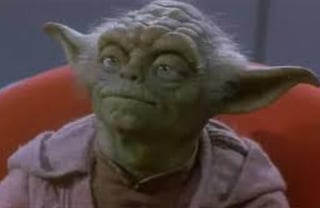

In [ ]:
# Test a sample
Image.open(image_df["image_path"].iloc[0])


In [ ]:
# Load visual concepts list
assets_dir = "/content/FakeNews/assets"
with open(os.path.join(assets_dir, "concepts_list.json"), "r") as f:
    concepts_list = json.load(f)

# Load visual concept embeddings
concept_embs = np.load(os.path.join(assets_dir, "concept_embeddings.npy"))
print(f"Loaded {len(concepts_list)} concepts and embedding matrix {concept_embs.shape}")

Loaded 1365 concepts and embedding matrix (1365, 512)


In [ ]:
# Load similarity bins
with open(os.path.join(assets_dir, "fakeddit_calibrated_sim_bins.json"), "r") as f:
    sim_bins = json.load(f)


# Models

Lood all the models to be used later.

In [ ]:
# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Log GPU specs (model, driver, VRAM)
try:
    smi = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=name,driver_version,memory.total", "--format=csv,noheader"],
        text=True
    ).strip()
    gpu_name, driver_version, vram_total = [x.strip() for x in smi.split(",")]
except Exception:
    gpu_name, driver_version, vram_total = "CPU/Unknown", None, None

In [ ]:
# CLIP
clip_name = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(clip_name)
clip_processor = CLIPProcessor.from_pretrained(clip_name)
clip_model.to(device)
clip_model.eval()
print("\n-----------------------------------------------------")
print("CLIP loaded successfully.")
print("-----------------------------------------------------")

# RoBERTa
roberta_name = "yaoyinnan/roberta-fakeddit"  # pretrained on Fakeddit dataset
roberta_tok = AutoTokenizer.from_pretrained(roberta_name)
roberta_model = AutoModelForSequenceClassification.from_pretrained(roberta_name)
roberta_model.to(device)
roberta_model.eval()
print("\n-----------------------------------------------------")
print("RoBERTa loaded successfully.")
print("-----------------------------------------------------")

# SentenceTransformer
sim_model = SentenceTransformer("all-mpnet-base-v2")
sim_model.to(device)
print("\n-----------------------------------------------------")
print("MPNet loaded successfully.")
print("-----------------------------------------------------")

# Sentiment Heuristic (VADER)
vader_analyzer = SentimentIntensityAnalyzer()

print("\n-----------------------------------------------------")
print("All models loaded successfully.")
print("-----------------------------------------------------")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


-----------------------------------------------------
MPNet loaded successfully.
-----------------------------------------------------

-----------------------------------------------------
All models loaded successfully.
-----------------------------------------------------


In [ ]:
# Helper to encode image
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

# LangChain Tools

Define the LangChain tools and format their outputs.

## Vision Tool

Gather all visual evidence through CLIP.

In [ ]:
# Define labels for CLIP prompts
label_prompts = [
    "an image used in a fake, misleading, possibly satire or clickbait news post",
    "an image used in a real and trustworthy news post"
]

In [ ]:
@tool
def vision_tool(image_path: str) -> dict:
    """
    Analyzes an image file.
    Returns: top visual concepts (CLIP), and Fake/Real classification (CLIP Zero-Shot).
    """
    image = Image.open(image_path).convert("RGB")

    # CLIP features (for concepts and zero-shot)
    inputs = clip_processor(images=image, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        img_emb = clip_model.get_image_features(**inputs)
    img_vec = img_emb.squeeze().cpu().numpy()

    # 1. Top-K Concepts
    k=3
    img_vec_norm = img_vec / norm(img_vec)
    concept_mags = norm(concept_embs, axis=1)
    concept_embs_norm = concept_embs / concept_mags[:, np.newaxis]
    sims = concept_embs_norm @ img_vec_norm
    topk_idx = sims.argsort()[::-1][:k]
    topk = [f"{concepts_list[i]} ({sims[i]:.2f})" for i in topk_idx]

    # 2. CLIP Zero-Shot
    text_inputs = clip_processor(text=label_prompts, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        text_embs = clip_model.get_text_features(**text_inputs)

    # Calculate similarity for ZS (manual dot product)
    text_embs_norm = text_embs / text_embs.norm(dim=1, keepdim=True)
    img_emb_norm = img_emb / img_emb.norm(dim=1, keepdim=True)
    logits = (img_emb_norm @ text_embs_norm.T).squeeze()
    probs = logits.softmax(dim=0).cpu().numpy()

    zs_pred_idx = np.argmax(probs)
    zs_label = "Real" if zs_pred_idx == 1 else "Fake"
    zs_conf = float(probs[zs_pred_idx])

    return {

            "visual_concepts": topk,
            "clip_zs_label": zs_label,
            "clip_zs_confidence": zs_conf
    }


Turn the quantitative evidence into a qualitative summary.

In [ ]:
def format_vision_evidence(tool_result: dict) -> str:
    """
    Turn raw vision_tool output into a short, human-readable summary
    for the vision agent to reason about.
    """
    # Extract fields with safe defaults
    label = tool_result.get("clip_zs_label")
    conf  = tool_result.get("clip_zs_confidence")
    concepts = tool_result.get("visual_concepts")

    # Map numeric confidence to a qualitative bucket
    if conf >= 0.8:
        conf_desc = "high"
    elif conf >= 0.5:
        conf_desc = "medium"
    else:
        conf_desc = "low"
    conf_str = f"{conf_desc} confidence (score ≈ {conf:.2f})"

    # Strip scores from concepts and keep only names
    # concept_names = [c.split("(")[0].strip() for c in concepts] # uncomment this to keep only names

    # Or keep both names and similarity weights
    concepts_str = ", ".join(concepts)  # join concept_names to keep only names
                                        # modify the summary lines accordingly

    # Write a summary for the llm agent
    summary_lines = [
        f"- The vision classifier's current guess for this image is: {label} with {conf_str}.",
        f"- The most relevant visual concepts (with similarity weights) detected are: {concepts_str}.",
    ]

    return "\n".join(summary_lines)


## Text Tool

Gather all textual evidence through RoBERTa and VADER.

In [ ]:
@tool
def text_tool(user_text: str) -> dict:
    """
    Analyzes the User Headline and computes VADER sentiment for the headline only.
    Returns: RoBERTa classification and VADER scores for the User Headline.
    """
    results = {}

    # 1. RoBERTa Classification
    inputs = roberta_tok(user_text, return_tensors="pt", truncation=True).to(device)
    with torch.no_grad():
        out = roberta_model(**inputs)
        probs = F.softmax(out.logits, dim=1).squeeze()

    pred_idx = torch.argmax(probs).item()
    label = "Fake" if pred_idx == 0 else "Real"
    conf = float(probs[pred_idx])

    # 2. VADER Sentiment
    sentiment = vader_analyzer.polarity_scores(user_text)["compound"]

    return {
        "roberta_label": label,
        "roberta_conf": conf,
        "vader_sentiment": sentiment
    }


Turn the quantitative evidence into a qualitative summary.

In [ ]:
def format_text_evidence(tool_result: dict) -> str:
    """
    Turn raw text_tool output into a short, human-readable summary
    for the text agent to reason about.
    """
    # Extract fields with safe defaults
    label = tool_result.get("roberta_label")
    conf  = tool_result.get("roberta_conf")
    sent  = tool_result.get("vader_sentiment")

    # Map numeric confidence to a qualitative bucket
    if conf >= 0.8:
        conf_desc = "high"
    elif conf >= 0.5:
        conf_desc = "medium"
    else:
        conf_desc = "low"
    conf_str = f"{conf_desc} confidence (score ≈ {conf:.2f})"

    # Map sentiment description from VADER compound score
    if sent >= 0.5:
        sent_label = "positive"
    elif sent <= -0.5:
        sent_label = "negative"
    else:
        sent_label = "neutral"
    sent_str = f"{sent_label} sentiment (compound ≈ {sent:.2f})"

    # Write a summary for the llm agent
    summary_lines = [
        f"- The text classifier's current guess for this headline is: {label} with {conf_str}.",
        f"- The headline's sentiment is: {sent_str}."
    ]

    return "\n".join(summary_lines)


## Context Tool

Gather all multimodal alignment evidence through MPNet and CLIP.

In [ ]:
@tool
def context_tool(user_text: str, AI_caption: str, image_path: str) -> dict:
    """
    Computes two-way alignment scores:
    1. Semantic: Text vs Caption
    2. Cross-modal: Image vs Text (User Claim Alignment)
    """
    # 1. Semantic Similarity (MPNet - Text-to-Text)
    emb1 = sim_model.encode(user_text, convert_to_tensor=True, device=device)
    emb2 = sim_model.encode(AI_caption, convert_to_tensor=True, device=device)
    st_sim = util.cos_sim(emb1, emb2).item()

    # 2. Cross-Modal Similarity (CLIP - Image-to-Text)
    image = Image.open(image_path).convert("RGB")

    # Get separate image & text features
    image_inputs = clip_processor(images=image, return_tensors="pt").to(device)
    text_inputs = clip_processor(text=[user_text], return_tensors="pt", padding=True).to(device)

    with torch.no_grad():
        img_feats = clip_model.get_image_features(**image_inputs)
        txt_feats = clip_model.get_text_features(**text_inputs)

    # Normalize to unit length
    img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True)
    txt_feats = txt_feats / txt_feats.norm(dim=-1, keepdim=True)

    # Cosine similarity: dot product of normalized vectors
    img_text_sim = float((img_feats @ txt_feats.T).squeeze().item())  # in [-1, 1]

    return {
        "text_to_caption_similarity": st_sim,
        "image_to_text_similarity": img_text_sim
    }


Turn the quantitative evidence into a qualitative summary.

In [ ]:
def format_context_evidence(tool_result: dict) -> str:
    """
    Turn raw context tool output into a short, human-readable
    summary for the context agent to reason about.
    """
    # Extract fields with safe defaults
    t2c = tool_result.get("text_to_caption_similarity")
    i2t = tool_result.get("image_to_text_similarity")

    # Get similarity bins for this subset
    t25, t50, t75 = sim_bins["t2c"]
    i25, i50, i75 = sim_bins["i2t"]

    # Map numeric similarity to a qualitative bucket
    def describe_by_bins(score: float, q25: float, q50: float, q75: float) -> str:
        """
        Dataset-relative description. Avoids absolute thresholds that may be misleading.
        """
        if score >= q75:
            hint = "stronger-than-usual (top quartile)"
        elif score >= q50:
            hint = "above typical (above median)"
        elif score >= q25:
            hint = "below typical (bottom half)"
        else:
            hint = "unusually low (bottom quartile)"
        return f"{hint} (score≈{score:.2f})"

    text_cap_str = describe_by_bins(t2c, t25, t50, t75)
    img_text_str = describe_by_bins(i2t, i25, i50, i75)

    # Write a summary for the llm agent
    summary_lines = [
        f"- Semantic alignment between the headline and caption: {text_cap_str}.",
        f"- Cross-modal alignment between the image and headline: {img_text_str}."
    ]

    return "\n".join(summary_lines)


# LangGraph Workflow

In [ ]:
# Set LLMs
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.0)
judge_llm = llm
# judge_llm = ChatOpenAI(model="gpt-4.1", temperature=0.0) # use a smarter model for judge agent

Define the graph state (Case file)

In [ ]:
class AgentState(TypedDict, total=False):
    # Inputs
    image_path: str
    headline: str
    caption: str

    # Forensic agent reports (text, what the Judge reads)
    vision_report: Optional[str]
    text_report: Optional[str]
    context_report: Optional[str]

    # Full JSON from each agent (for later analysis)
    vision_raw: Optional[dict]
    text_raw: Optional[dict]
    context_raw: Optional[dict]

    # Final output
    judge_report: Optional[str]
    judge_raw: Optional[dict]


Define the nodes (Forensics - Local Level)

## Vision Node

In [ ]:
def vision_node(state: AgentState) -> AgentState:
    """
    Role: Graphics Forensics Expert
    Input: Image (via Path)
    Phases: 1. Look (as GPT) -> 2. Verify (with CLIP) -> 3. Report (to GPT)
    """
    print("\nVision Agent: Collecting graphical evidence...")

    # Run Tool to gather forensic evidence
    image_path = state["image_path"]
    tool_result = vision_tool.invoke({"image_path": image_path})
    vision_evidence = format_vision_evidence(tool_result)

    # Encode image for the agent
    base64_img = encode_image(image_path)

    # Define the instruction message (system role)
    system_msg = """
    You are a VISION FORENSIC AGENT in a misinformation investigation.

    SCOPE:
    - Your mission is to detect whether the image is likely associated with real, benign news or with fake, deceptive news.
    - Your forensic department provided you with the evidence obtained through a forensic toolkit.
    - You report your findings to the Judge.

    FORENSIC TOOLKIT:
    - Analyzes the user-provided image.
    - Vision Classifier: Flags the image as potentially Fake or Real.
    - Visual Concept Detector: Detects visual concepts or objects in the image.
    - Classifier and detector are separate tools; treat their results as independent signals.

    IMPORTANT:
    - Your final decision should NOT simply repeat your initial impression; it must synthesize the tool's summary.
    - Do NOT assume an image is "Fake" just because it looks illustrated, painted, drawn or designed; a non real-life photo can also be real.
    - Reserve "Fake" for cases where the image itself is misleading, manipulated or deceptive as evidence.

    PROTOCOL:
    Follow this three-step protocol to write your report:
    1) Intuition: Inspect the image. Give an initial hunch about the news authenticity: Real or Fake, and why.
    2) Forensics: Use the forensic tool results as noisy evidence that may support or challenge your hunch.
    3) Synthesis: Give a final decision about the news authenticity, note if you changed your mind, and set confidence (High/Medium/Low).

    CONFIDENCE FIELD:
    When setting "confidence":
    - Use "High" if forensic evidence clearly supports your decision.
    - Use "Medium" if forensic evidence is mixed but leans toward your decision.
    - Use "Low" if forensic evidence is weak or conflicting and you had to choose despite uncertainty.

    OUTPUT:
    Return a single JSON object with keys:
    {{
      "initial_impression": "Real" or "Fake",
      "initial_reasoning": "Brief summary of your initial impression.",
      "final_decision": "Real" or "Fake",
      "changed_mind": "Yes" or "No",
      "confidence": "High" or "Medium" or "Low",
      "report": "A narrative paragraph (3–5 sentences) for the Judge to read."
    }}
    """.strip()

    # Define the input message (human role - text part)
    human_msg = f"""
    Please analyze the following image and its forensic summary in a misinformation case.

    IMAGE PATH: {image_path}

    FORENSIC SUMMARY: {vision_evidence}

    The actual image is also attached for your direct visual observation.
    """.strip()

    # Build prompt
    prompt = ChatPromptTemplate.from_messages([
        ("system", system_msg),
        ("human", [
            {"type": "text", "text": human_msg},
            {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{base64_img}"}},
        ]),
    ])

    chain = prompt | llm | JsonOutputParser()
    result = chain.invoke({})  # result is a dict with keys inc. "report"

    # Extract the narrative report for the Judge
    report = result["report"]

    return {
        "vision_report": report,  # what Judge reads
        "vision_raw": result,     # full JSON for analysis
    }

## Text Node

In [ ]:
def text_node(state: AgentState) -> AgentState:
    """
    Role: Linguistic Forensics Expert
    Input: Headline (Text)
    Phases: 1. Read (as GPT) -> 2. Verify (with RoBERTa+Vader) -> 3. Report (to GPT)
    """
    print("\nText Agent: Collecting linguistic evidence...")

    # Run Tool to gather forensic evidence
    headline = state["headline"]
    tool_result = text_tool.invoke({"user_text": headline})
    text_evidence = format_text_evidence(tool_result)

    # Define the instruction message (system role)
    system_msg = """
    You are a LINGUISTIC FORENSIC AGENT in a misinformation investigation.

    SCOPE:
    - Your mission is to detect whether the headline is likely associated with real, benign news or with fake, deceptive news.
    - Your forensic department provided you with the evidence obtained through a forensic toolkit.
    - You report your findings to the Judge.

    FORENSIC TOOLKIT:
    - Analyzes the user-provided headline.
    - Flags the headline as potentially Fake or Real using a text classifier.
    - Measures the headline's sentiment (e.g., sensationalism) using a sentiment analyzer.

    IMPORTANT:
    - Your final decision should NOT simply repeat your initial impression; it must synthesize the tool's summary.
    - Do NOT call a headline "Fake" solely because it is emotional, sarcastic, or strongly worded.
    - Reserve "Fake" for the content that is factually fabricated or deceptive.

    PROTOCOL:
    Follow this three-step protocol to write your report:
    1) Intuition: Inspect the headline. Give an initial hunch about the news authenticity: Real or Fake, and why.
    2) Forensics: Use the forensic tool results as noisy evidence that may support or challenge your hunch.
    3) Synthesis: Give a final decision about the news authenticity, note if you changed your mind, and set confidence (High/Medium/Low).

    CONFIDENCE FIELD:
    When setting "confidence":
    - Use "High" if forensic evidence clearly supports your decision.
    - Use "Medium" if forensic evidence is mixed but leans toward your decision.
    - Use "Low" if forensic evidence is weak or conflicting and you had to choose despite uncertainty.

    OUTPUT:
    Return a single JSON object with keys:
    {{
      "initial_impression": "Real" or "Fake",
      "initial_reasoning": "Brief summary of your initial impression.",
      "final_decision": "Real" or "Fake",
      "changed_mind": "Yes" or "No",
      "confidence": "High" or "Medium" or "Low",
      "report": "A narrative paragraph (3–5 sentences) for the Judge to read."
    }}
    """.strip()

    # Define the input message (human role - text part)
    human_msg = f"""
    Please analyze the following headline and its forensic summary in a misinformation case.

    HEADLINE: {headline}

    FORENSIC SUMMARY: {text_evidence}
    """.strip()

    # Build prompt
    prompt = ChatPromptTemplate.from_messages([
        ("system", system_msg),
        ("human", human_msg),
    ])

    chain = prompt | llm | JsonOutputParser()
    result = chain.invoke({})
    report = result["report"]

    return {
        "text_report": report,
        "text_raw": result,
    }

## Context Node

In [ ]:
def context_node(state: AgentState) -> AgentState:
    """
    Role: Context Forensics Expert
    Input: Image + Headline + Caption
    Phases: 1. Look and Read (as GPT) -> 2. Verify (with MPNet+CLIP) -> 3. Report (to GPT)
    """
    print("\nContext Agent: Collecting contextual evidence...")

    # Run Tool to gather forensic evidence
    headline = state["headline"]
    caption = state["caption"]
    image_path = state["image_path"]
    tool_result = context_tool.invoke({
        "user_text": headline,
        "AI_caption": caption,
        "image_path": image_path
    })
    context_evidence = format_context_evidence(tool_result)

    # Encode image for the agent
    base64_img = encode_image(state["image_path"])

    # Define the instruction message (system role)
    system_msg = """
    You are a CONTEXT FORENSIC AGENT in a misinformation investigation.

    SCOPE:
    - Your mission is to detect whether the image, headline, caption form a coherent, authentic context or show signs of generic or even contradictory usage.
    - Your forensic department provided you with the evidence obtained through a forensic toolkit.
    - You report your findings to the Judge.

    FORENSIC TOOLKIT:
    - Analyzes the user-provided image and headline, and AI-generated caption of the image together.
    - Measures how well the headline and caption align semantically.
    - Measures cross-modal alignment between the image and headline.

    IMPORTANT:
    - Your final decision should NOT simply repeat your initial impression; it must synthesize the tool's summary.
    - Reserve "Aligned" for when both semantic alignment and cross-modal alignment are above typical (above median) or stronger-than-usual (top quartile).
    - Reserve "Generic" for when one or both alignments are below typical (bottom half) but there is no clear contradiction.
    - Reserve "Mismatch" only for when both semantic alignment and cross-modal alignment are unusually low (bottom quartile) and there is an identifiable reason.

    PROTOCOL:
    Follow this three-step protocol to write your report:
    1) Intuition: Inspect the image, headline, and caption. Give an initial hunch: Aligned or Generic or Mismatch, and why.
    2) Forensics: Use the forensic tool results as noisy evidence that may support or challenge your hunch.
    3) Synthesis: Give a final decision about the context alignment, note if you changed your mind, and set confidence (High/Medium/Low).

    CONFIDENCE FIELD:
    When setting "confidence":
    - Use "High" if forensic evidence clearly supports your decision.
    - Use "Medium" if forensic evidence is mixed but leans toward your decision.
    - Use "Low" if forensic evidence is weak or conflicting and you had to choose despite uncertainty.

    OUTPUT:
    Return a single JSON object with keys:
    {{
      "initial_impression": "Aligned" or "Generic" or "Mismatch",
      "initial_reasoning": "Brief summary of your initial impression.",
      "final_decision": "Aligned" or "Generic" or "Mismatch",
      "changed_mind": "Yes" or "No",
      "confidence": "High" or "Medium" or "Low",
      "report": "A narrative paragraph (3–5 sentences) for the Judge to read."
    }}
    """.strip()

    # Define the input message (human role - text part)
    human_msg = f"""
    Please analyze the following image, headline, caption and their forensic summary in a misinformation case.

    IMAGE PATH: {image_path}
    HEADLINE: {headline}
    CAPTION: {caption}

    FORENSIC SUMMARY: {context_evidence}

    The actual image is also attached for your direct visual observation.
    """.strip()

    # Build prompt
    prompt = ChatPromptTemplate.from_messages([
        ("system", system_msg),
        ("human", [
            {"type": "text", "text": human_msg},
            {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{base64_img}"}},
        ]),
    ])

    chain = prompt | llm | JsonOutputParser()
    result = chain.invoke({})
    report = result["report"]

    return {
        "context_report": report,
        "context_raw": result,
    }

## Judge Node

Define the master node (Judge - Global Level)

In [ ]:
def judge_node(state: AgentState):
    """
    Role: The Judge
    Input: Image + Headline + 3 Reports
    Logic: Intuition -> Forensic Reports -> Verdict
    """
    print("\nJudge Agent: Reading all forensics reports...")

    # Core inputs
    image_path = state["image_path"]
    headline = state["headline"]
    base64_img = encode_image(state["image_path"])

    # Forensic reports from specialist agents
    vision_report = state["vision_report"]
    text_report = state["text_report"]
    context_report = state["context_report"]

    # Confidence of agents
    vision_conf = state["vision_raw"].get("confidence")
    text_conf = state["text_raw"].get("confidence")
    context_conf = state["context_raw"].get("confidence")

    # Define the instruction message (system role)
    system_msg = """
    You are the JUDGE in a multimodal misinformation investigation.

    SCOPE:
    - Your mission is to decide whether a news item (image + headline) is more likely associated with real/benign content or fake/misleading content.
    - You receive forensic reports from three specialist agents, each focusing on a different aspect: visual, linguistic, and contextual authenticity.
    - Integrating these reports, you provide a clear final decision and rationale to a human decision-maker.

    FORENSIC AGENTS:
    - Vision Agent: focuses on image authenticity.
    - Text Agent: focuses on headline realism and linguistic cues.
    - Context Agent: focuses on how well image, headline, and caption align.

    IMPORTANT:
    - Your final decision should NOT simply repeat your initial impression; it must synthesize the agents' expertise.
    - Treat each forensic report as noisy but expert evidence. Agents may disagree because their evidence sources have different strengths and limitations.
    - Use each agent's "confidence" as a proxy for reliability:
      - High confidence = strong, trustworthy evidence.
      - Medium confidence = useful but should be weighed with caution.
      - Low confidence = weak or uncertain evidence; do not let it dominate the decision.
    - When agents disagree:
      - Look at how many agents support Real vs Fake.
      - Give more weight to agents that are both (a) confident and (b) well-aligned with the other reports.
      - If most high-confidence agents agree on one side, you should usually adopt that side, even if your initial impression was different.
      - Generic context is NOT a disagreement and does NOT mean the news is fake; it simply indicates weak alignment, likely due to generic content.
    - When setting your own "confidence":
      - Use "High" if forensic reports clearly and consistently support your decision.
      - Use "Medium" if forensic reports are somewhat mixed but overall lean toward your decision.
      - Use "Low" if forensic reports are weak or conflicting and you had to choose despite uncertainty.

    PROTOCOL:
    Follow this three-step protocol to produce your final decision:
    1) Intuition (Global):
       - First, inspect ONLY the image and headline.
       - Form an initial hunch: "Real" or "Fake", and briefly explain why.
       - In this step, do NOT rely on the forensic reports yet.

    2) Forensics (Read Reports):
       - Carefully read the Vision, Text, and Context reports.
       - Identify where they agree or disagree.
       - Reflect on whether they support or challenge your initial hunch.

    3) Synthesis (Verdict):
       - Decide a final judgment for the news item: "Real" or "Fake".
       - State explicitly whether you changed your mind after reading the reports.
       - Indicate which source of evidence contributed most to your final decision: "Vision Report" or "Text Report" or "Context Report".
       - Set a confidence level (High/Medium/Low) based on the agreement/strength of evidence.
       - Write a short explanation suitable for the public.
       - Give one practical nudge: how a user could think more critically about similar content.

    OUTPUT:
    Return a single JSON object with keys:
    {{
      "initial_impression": "Real" or "Fake",
      "initial_reasoning": "Brief summary of your initial impression.",
      "final_decision": "Real" or "Fake",
      "changed_mind": "Yes" or "No",
      "evidence_source": "Vision Report" or "Text Report" or "Context Report",
      "confidence": "High" or "Medium" or "Low",
      "explanation": "A narrative paragraph (3–5 sentences) to the public. Start with your intuition and explain how the forensic reports confirmed or refuted your initial thought.",
      "nudge": "One actionable piece of advice to the public."
    }}
    """.strip()

    # Define the input message (human role - text part)
    human_msg = f"""
    Please analyze the following news item (image and headline), three forensic reports in a misinformation case and the confidence of each forensic agent.

    NEWS:
    - IMAGE PATH: {image_path}
    - HEADLINE: {headline}

    FORENSIC REPORTS:
    - VISION AGENT REPORT: {vision_report}
    - TEXT AGENT REPORT: {text_report}
    - CONTEXT AGENT REPORT: {context_report}

    AGENT CONFIDENCE:
    - VISION AGENT: {vision_conf}
    - TEXT AGENT: {text_conf}
    - CONTEXT AGENT: {context_conf}

    The actual image is also attached for your direct visual observation.
    """.strip()

    # Build prompt
    prompt = ChatPromptTemplate.from_messages([
        ("system", system_msg),
        ("human", [
            {"type": "text", "text": human_msg},
            {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{base64_img}"}},
        ]),
    ])

    # Generate Output
    chain = prompt | judge_llm | JsonOutputParser()
    result = chain.invoke({})
    report = result["explanation"]

    return {
        "judge_report": report,
        "judge_raw": result,
    }

## Compiler

Compile the graph (Architecture)

In [ ]:
# Set compiler
workflow = StateGraph(AgentState)

# Add Nodes
workflow.add_node("vision_agent", vision_node)
workflow.add_node("text_agent", text_node)
workflow.add_node("context_agent", context_node)
workflow.add_node("judge_agent", judge_node)

# Add Edges (Sequential Execution) START -> Vision -> Text -> Alignment -> Supervisor -> END
workflow.set_entry_point("vision_agent") # Or a "Router" node if you want true parallel start
workflow.add_edge("vision_agent", "text_agent") # Sequential for simplicity in v1
workflow.add_edge("text_agent", "context_agent")
workflow.add_edge("context_agent", "judge_agent")
workflow.add_edge("judge_agent", END)

# Compile
app = workflow.compile()


# Pipeline

In [ ]:
# Run pipeline
results = []

# Start timer
T0 = time.perf_counter()

for i, row in tqdm(image_df.iterrows(), total=len(image_df)): # use sample_df for N samples
    state_in = {
        "image_path": row["image_path"],
        "headline": row["clean_title"],
        "caption": row["blip2_caption"],
    }

    try:
        out_state = app.invoke(state_in)

        # Get vision, text, judge agent results
        v_raw = out_state.get("vision_raw")
        t_raw = out_state.get("text_raw")
        c_raw = out_state.get("context_raw")
        j_raw = out_state.get("judge_raw")

        results.append({
            # metadata
            "image_path": row["image_path"],
            "headline":   row["clean_title"],
            "caption":    row["blip2_caption"],
            "true_label": row["label"],

            # vision agent
            "vision_initial":    v_raw.get("initial_impression"),
            "vision_ireasoning": v_raw.get("initial_reasoning"),
            "vision_final":      v_raw.get("final_decision"),
            "vision_changed":    v_raw.get("changed_mind"),
            "vision_conf":       v_raw.get("confidence"),
            "vision_report":     v_raw.get("report"),

            # text agent
            "text_initial":    t_raw.get("initial_impression"),
            "text_ireasoning": t_raw.get("initial_reasoning"),
            "text_final":      t_raw.get("final_decision"),
            "text_changed":    t_raw.get("changed_mind"),
            "text_conf":       t_raw.get("confidence"),
            "text_report":     t_raw.get("report"),

            # context agent
            "context_initial":    c_raw.get("initial_impression"),
            "context_ireasoning": c_raw.get("initial_reasoning"),
            "context_final":      c_raw.get("final_decision"),
            "context_changed":    c_raw.get("changed_mind"),
            "context_conf":       c_raw.get("confidence"),
            "context_report":     c_raw.get("report"),

            # judge agent
            "judge_initial":    j_raw.get("initial_impression"),
            "judge_ireasoning": j_raw.get("initial_reasoning"),
            "judge_final":      j_raw.get("final_decision"),
            "judge_changed":    j_raw.get("changed_mind"),
            "evidence_source":  j_raw.get("evidence_source"),
            "judge_conf":       j_raw.get("confidence"),
            "judge_report":     j_raw.get("explanation"),
            "judge_nudge":      j_raw.get("nudge"),

            # full json for debugging
            "vision_json":   json.dumps(v_raw),
            "text_json":     json.dumps(t_raw),
            "context_json":  json.dumps(c_raw),
            "judge_json":    json.dumps(j_raw),
        })

    except Exception as e:
        print(f"Error on row {i}: {e}")
        results.append({
            "idx": i,
            "image_path": row["image_path"],
            "headline":   row["clean_title"],
            "caption":    row["blip2_caption"],
            "true_label": row["label"],
            "error": str(e),
        })

# Stop timer
T1 = time.perf_counter()
print(f"\nTotal runtime: {(T1 - T0)/60:.2f} min  ({T1 - T0:.1f} sec)")

# Save results
results_df = pd.DataFrame(results)
print("\nProcessing Complete.")
results_df.head()

  0%|          | 0/150 [00:00<?, ?it/s]


Vision Agent: Collecting graphical evidence...

Text Agent: Collecting linguistic evidence...

Context Agent: Collecting contextual evidence...

Judge Agent: Reading all forensics reports...


  1%|          | 1/150 [00:16<42:06, 16.96s/it]


Vision Agent: Collecting graphical evidence...

Text Agent: Collecting linguistic evidence...

Context Agent: Collecting contextual evidence...

Judge Agent: Reading all forensics reports...


  1%|▏         | 2/150 [00:29<34:48, 14.11s/it]

...

 99%|█████████▉| 149/150 [29:59<00:14, 14.73s/it]


Vision Agent: Collecting graphical evidence...

Text Agent: Collecting linguistic evidence...

Context Agent: Collecting contextual evidence...

Judge Agent: Reading all forensics reports...


100%|██████████| 150/150 [30:12<00:00, 12.09s/it]


Total runtime: 30.21 min  (1812.8 sec)

Processing Complete.


,image_path,headline,caption,true_label,vision_initial,vision_ireasoning,vision_final,vision_changed,vision_conf,vision_report,...,judge_final,judge_changed,evidence_source,judge_conf,judge_report,judge_nudge,vision_json,text_json,context_json,judge_json
0,/content/FakeNews/assets/content/fakeddit_imag...,bernie sander announces his campaign for presi...,"yoda is sitting in a chair with the caption, ""...",0,Fake,The image depicts a well-known fictional chara...,Fake,No,High,"The image clearly shows Yoda, a fictional char...",...,Fake,No,Vision Report,High,My initial impression was that this news item ...,Always check if the image matches the headline...,"{""initial_impression"": ""Fake"", ""initial_reason...","{""initial_impression"": ""Fake"", ""initial_reason...","{""initial_impression"": ""Mismatch"", ""initial_re...","{""initial_impression"": ""Fake"", ""initial_reason..."
1,/content/FakeNews/assets/content/fakeddit_imag...,my dom nsfw,a woman is standing in front of microphones,0,Real,The image shows a woman speaking at a podium w...,Real,No,Medium,The image depicts a woman addressing the media...,...,Fake,No,Text Report,High,"Initially, the image appeared authentic as it ...",Always check if the headline meaningfully rela...,"{""initial_impression"": ""Real"", ""initial_reason...","{""initial_impression"": ""Fake"", ""initial_reason...","{""initial_impression"": ""Mismatch"", ""initial_re...","{""initial_impression"": ""Fake"", ""initial_reason..."
2,/content/FakeNews/assets/content/fakeddit_imag...,my inlaws moved into a building that hasnt upd...,a room with purple walls and green furniture,1,Real,The image depicts a typical living room setup ...,Real,No,Medium,"The image shows a living room with couches, ch...",...,Real,No,Text Report,High,My initial impression was that the news item i...,"When encountering similar posts, consider whet...","{""initial_impression"": ""Real"", ""initial_reason...","{""initial_impression"": ""Real"", ""initial_reason...","{""initial_impression"": ""Aligned"", ""initial_rea...","{""initial_impression"": ""Real"", ""initial_reason..."
3,/content/FakeNews/assets/content/fakeddit_imag...,a leaf fell perfectly in the wet cement,a leaf on the sidewalk,1,Real,The image shows a leaf embedded or imprinted i...,Real,No,Medium,The image depicts a leaf pattern embedded in c...,...,Real,No,Context Report,High,My initial impression was that the news item i...,"When encountering simple, natural phenomena in...","{""initial_impression"": ""Real"", ""initial_reason...","{""initial_impression"": ""Real"", ""initial_reason...","{""initial_impression"": ""Aligned"", ""initial_rea...","{""initial_impression"": ""Real"", ""initial_reason..."
4,/content/FakeNews/assets/content/fakeddit_imag...,a philadelphia bar cut a hall of famers baseba...,a baseball card with a picture of a man on it,1,Real,The image appears to be a genuine baseball car...,Real,No,Medium,The image shows a baseball card of a player na...,...,Real,Yes,Context Report,Medium,"Initially, the headline seemed implausible and...",When encountering surprising or unusual claims...,"{""initial_impression"": ""Real"", ""initial_reason...","{""initial_impression"": ""Fake"", ""initial_reason...","{""initial_impression"": ""Aligned"", ""initial_rea...","{""initial_impression"": ""Fake"", ""initial_reason..."


# Evaluation

Compare pre vs. post performance for Vision, Text, and Judge agents (pre vs. post = initial impression vs. final decision).

In [ ]:
# Convert textual labels to ints
def label_to_int(x):
    if str(x).lower() == "fake":  return 0
    if str(x).lower() == "real":  return 1
    return None  # for errors / missing / unexpected values

# Make a new df for evaluation
eval_df = pd.DataFrame({
    "true_label": results_df["true_label"].astype(int),
    "va_pre":  results_df["vision_initial"].apply(label_to_int),
    "va_post": results_df["vision_final"].apply(label_to_int),
    "ta_pre":  results_df["text_initial"].apply(label_to_int),
    "ta_post": results_df["text_final"].apply(label_to_int),
    "ja_pre":  results_df["judge_initial"].apply(label_to_int),
    "ja_post": results_df["judge_final"].apply(label_to_int),
})


In [ ]:
# Accuracies
va1_acc = np.mean(eval_df["va_pre"]  == eval_df["true_label"])
va2_acc = np.mean(eval_df["va_post"] == eval_df["true_label"])
ta1_acc = np.mean(eval_df["ta_pre"]  == eval_df["true_label"])
ta2_acc = np.mean(eval_df["ta_post"] == eval_df["true_label"])
ja1_acc = np.mean(eval_df["ja_pre"]  == eval_df["true_label"])
ja2_acc = np.mean(eval_df["ja_post"] == eval_df["true_label"])

print("Vision Agent (pre)  accuracy:", round(va1_acc, 3))
print("Vision Agent (post) accuracy:", round(va2_acc, 3))
print("Text Agent   (pre)  accuracy:", round(ta1_acc, 3))
print("Text Agent   (post) accuracy:", round(ta2_acc, 3))
print("Judge Agent  (pre)  accuracy:", round(ja1_acc, 3))
print("Judge Agent  (post) accuracy:", round(ja2_acc, 3))


Vision Agent (pre)  accuracy: 0.613
Vision Agent (post) accuracy: 0.613
Text Agent   (pre)  accuracy: 0.84
Text Agent   (post) accuracy: 0.913
Judge Agent  (pre)  accuracy: 0.76
Judge Agent  (post) accuracy: 0.813


In [ ]:
# Confusion matrices

va1_cm = confusion_matrix(eval_df["true_label"], eval_df["va_pre"])
va2_cm = confusion_matrix(eval_df["true_label"], eval_df["va_post"])
ta1_cm = confusion_matrix(eval_df["true_label"], eval_df["ta_pre"])
ta2_cm = confusion_matrix(eval_df["true_label"], eval_df["ta_post"])
ja1_cm = confusion_matrix(eval_df["true_label"], eval_df["ja_pre"])
ja2_cm = confusion_matrix(eval_df["true_label"], eval_df["ja_post"])

print("\nVision Agent (pre) Confusion Matrix:\n", va1_cm)
print("\nVision Agent (post) Confusion Matrix:\n", va2_cm)
print("\nText Agent (pre) Confusion Matrix:\n", ta1_cm)
print("\nText Agent (post) Confusion Matrix:\n", ta2_cm)
print("\nJudge Agent (pre) Confusion Matrix:\n", ja1_cm)
print("\nJudge Agent (post) Confusion Matrix:\n", ja2_cm)



Vision Agent (pre) Confusion Matrix:
 [[34 41]
 [17 58]]

Vision Agent (post) Confusion Matrix:
 [[34 41]
 [17 58]]

Text Agent (pre) Confusion Matrix:
 [[56 19]
 [ 5 70]]

Text Agent (post) Confusion Matrix:
 [[68  7]
 [ 6 69]]

Judge Agent (pre) Confusion Matrix:
 [[59 16]
 [20 55]]

Judge Agent (post) Confusion Matrix:
 [[65 10]
 [18 57]]


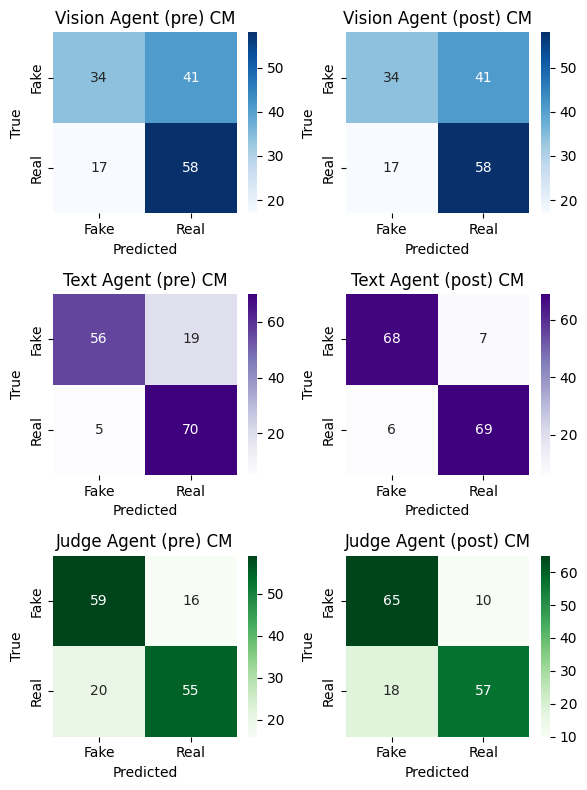

In [ ]:
# Heatmaps
fig, axes = plt.subplots(3, 2, figsize=(6, 8))
axes = axes.ravel()  # flatten to 1D: axes[0]..axes[3]

# Vision Agent Pre-Post
sns.heatmap(va1_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"],
            ax=axes[0])
axes[0].set_title("Vision Agent (pre) CM")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(va2_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"],
            ax=axes[1])
axes[1].set_title("Vision Agent (post) CM")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

# Text Agent Pre-Post
sns.heatmap(ta1_cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"],
            ax=axes[2])
axes[2].set_title("Text Agent (pre) CM")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("True")

sns.heatmap(ta2_cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"],
            ax=axes[3])
axes[3].set_title("Text Agent (post) CM")
axes[3].set_xlabel("Predicted")
axes[3].set_ylabel("True")

# Judge Agent Pre-Post
sns.heatmap(ja1_cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"],
            ax=axes[4])
axes[4].set_title("Judge Agent (pre) CM")
axes[4].set_xlabel("Predicted")
axes[4].set_ylabel("True")

sns.heatmap(ja2_cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"],
            ax=axes[5])
axes[5].set_title("Judge Agent (post) CM")
axes[5].set_xlabel("Predicted")
axes[5].set_ylabel("True")

plt.tight_layout()
plt.show()

In [ ]:
# Classification reports
print("\n-----------------------------------------------------")
print("Vision Agent (pre) Classification Report:")
print("-----------------------------------------------------")
print(classification_report(
    eval_df["true_label"],
    eval_df["va_pre"],
    target_names=["Fake", "Real"]
))

print("\n-----------------------------------------------------")
print("Vision Agent (post) Classification Report:")
print("-----------------------------------------------------")
print(classification_report(
    eval_df["true_label"],
    eval_df["va_post"],
    target_names=["Fake", "Real"]
))

print("\n-----------------------------------------------------")
print("Text Agent (pre) Classification Report:")
print("-----------------------------------------------------")
print(classification_report(
    eval_df["true_label"],
    eval_df["ta_pre"],
    target_names=["Fake", "Real"]
))

print("\n-----------------------------------------------------")
print("Text Agent (post) Classification Report:")
print("-----------------------------------------------------")
print(classification_report(
    eval_df["true_label"],
    eval_df["ta_post"],
    target_names=["Fake", "Real"]
))

print("\n-----------------------------------------------------")
print("Judge Agent (pre) Classification Report:")
print("-----------------------------------------------------")
print(classification_report(
    eval_df["true_label"],
    eval_df["ja_pre"],
    target_names=["Fake", "Real"]
))

print("\n-----------------------------------------------------")
print("Judge Agent (post) Classification Report:")
print("-----------------------------------------------------")
print(classification_report(
    eval_df["true_label"],
    eval_df["ja_post"],
    target_names=["Fake", "Real"]
))


-----------------------------------------------------
Vision Agent (pre) Classification Report:
-----------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.67      0.45      0.54        75
        Real       0.59      0.77      0.67        75

    accuracy                           0.61       150
   macro avg       0.63      0.61      0.60       150
weighted avg       0.63      0.61      0.60       150


-----------------------------------------------------
Vision Agent (post) Classification Report:
-----------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.67      0.45      0.54        75
        Real       0.59      0.77      0.67        75

    accuracy                           0.61       150
   macro avg       0.63      0.61      0.60       150
weighted avg       0.63      0.61      0.60       150


------------------------------------------

# Log

In [ ]:
# Show runtime
runtime_sec = T1 - T0
print(f"Total runtime: {runtime_sec/60:.2f} min ({runtime_sec:.1f} sec)")

# Show GPU specs
display(gpu_name, driver_version, vram_total)

Total runtime: 30.21 min (1812.8 sec)


'NVIDIA L4'

'550.54.15'

'23034 MiB'

In [ ]:
# Log runtime and gpu specs
log = {
    "pipeline": "Multi_Agent_Hierarchical",
    "n_samples": len(image_df),
    "runtime_sec": runtime_sec,
    "gpu_name": gpu_name,
    "driver_version": driver_version,
    "vram_total": vram_total,
}
print(log)

{'pipeline': 'Multi_Agent_Hierarchical', 'n_samples': 150, 'runtime_sec': 1812.780384713, 'gpu_name': 'NVIDIA L4', 'driver_version': '550.54.15', 'vram_total': '23034 MiB'}


# Save

In [ ]:
# Save logs
with open("MAH_runtime_log.jsonl", "a") as f:
    f.write(json.dumps(log) + "\n")

In [ ]:
# Save results_df
results_df.to_csv("MAH_results_df.csv", index=False)

# Save eval_df
eval_df.to_csv("MAH_eval_df.csv", index=False)